# Greek Sign Language Public Service Recognition Project

This notebook represents the refined, organized version of the project based on the Greek Sign Language (GSL) dataset.
The project focuses on a specific domain: citizen services.
It does not attempt to translate general, everyday conversations into sign language.
Instead, it recognizes predefined sentences and dialogues contained within the dataset.

What we will do:
Mount Google Drive.
Properly read the annotation files from `GSL_continuous_files`.
Analyze the dataset.
Select a small subset to avoid exceeding Colab's storage limits.
Extract only the necessary videos from `GSL_continuous.tar.gz`.
Extract landmarks using MediaPipe Holistic.
Train a GRU, LSTM, or Transformer model.
Visualize the results.
Create a Streamlit application for citizen services.

## Structural diagram workflow

```text
Google Drive Dataset
│
├── GSL_continuous_files/*.csv
│       │
│       └── annotations:
│           video_key | gloss_sentence
│
├── GSL_continuous.tar.gz
│       │
│       └── sentence videos
│
↓
Read annotations
↓
Dataset analysis
↓
Select small public-service subset
↓
Extract only selected videos from tar.gz
↓
MediaPipe Holistic preprocessing
↓
Landmark sequences
    60 frames × 258 features
↓
Train sequence model
    GRU / LSTM / Transformer
↓
Evaluation
    Accuracy, Top-k accuracy, Classification report, Confusion matrix
↓
Export model + encoder + normalization stats
↓
Streamlit Public Service Assistant
    upload video → predicted GSL gloss sentence → natural Greek response
```

## Cell 1 — Install libraries

Using:

- `opencv-python` for video processing
- `mediapipe` for hand/body landmarks
- `tensorflow` for GRU/LSTM/Transformer
- `scikit-learn` for metrics and label encoding
- `streamlit` for the final application

In [3]:
!pip uninstall -y tensorflow tensorflow-text tf-keras keras opencv-python opencv-python-headless opencv-contrib-python mediapipe numpy protobuf

!pip install -q \
  numpy==1.26.4 \
  protobuf==4.25.9 \
  tensorflow==2.19.1 \
  keras==3.10.0 \
  mediapipe==0.10.21 \
  opencv-python==4.10.0.84 \
  scikit-learn \
  pandas \
  matplotlib \
  joblib \
  tqdm \
  streamlit

Found existing installation: tensorflow 2.19.1
Uninstalling tensorflow-2.19.1:
  Successfully uninstalled tensorflow-2.19.1
Found existing installation: tensorflow-text 2.20.1
Uninstalling tensorflow-text-2.20.1:
  Successfully uninstalled tensorflow-text-2.20.1
Found existing installation: tf_keras 2.20.0
Uninstalling tf_keras-2.20.0:
  Successfully uninstalled tf_keras-2.20.0
Found existing installation: keras 3.13.2
Uninstalling keras-3.13.2:
  Successfully uninstalled keras-3.13.2
Found existing installation: opencv-python 4.11.0.86
Uninstalling opencv-python-4.11.0.86:
  Successfully uninstalled opencv-python-4.11.0.86
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
Found existing installation: opencv-contrib-python 4.11.0.86
Uninstalling opencv-contrib-python-4.11.0.86:
  Successfully uninstalled opencv-contrib-python-4.11.0.86
Found existing installation: medi

The above are warnings/conflicts from packages that Colab already has but the installation has executed successfully. With the above code we can check that MediaPipe solutions exists so everything is OK and we can continue.

In [1]:
import numpy as np
import cv2
import mediapipe as mp
import tensorflow as tf
import keras
import pandas as pd
import sklearn

print("numpy:", np.__version__)
print("opencv:", cv2.__version__)
print("mediapipe:", mp.__version__)
print("tensorflow:", tf.__version__)
print("keras:", keras.__version__)
print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)

print("MediaPipe solutions exists:", hasattr(mp, "solutions"))

numpy: 1.26.4
opencv: 4.11.0
mediapipe: 0.10.21
tensorflow: 2.19.1
keras: 3.10.0
pandas: 2.2.2
sklearn: 1.6.1
MediaPipe solutions exists: True


## Cell 2 — Connect to Google Drive

The dataset is located to Google Drive as a shortcut:

```text
/content/drive/MyDrive/GSL Dataset/
```

With mount we can use it in Colab without download it in our laptop since it is too large.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cell 3 — Imports and basic settings

We load some basics libaries and we define paths

Important paths:

- `DATASET_ROOT`:dataset's file in Drive
- `CONT_FILES`: annotations for continuous videos
- `CONT_TAR`: compressed files with the continuous videos
- `OUTPUT_DIR`: folder in Drive where processed landmarks, models and reports will be saved

In [3]:
from pathlib import Path
import os
import re
import json
import tarfile
import shutil
import random
import warnings

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    top_k_accuracy_score
)

import tensorflow as tf
from tensorflow.keras import layers, models

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_ROOT = Path("/content/drive/MyDrive/GSL Dataset")

ISO_TAR = DATASET_ROOT / "GSL_isolated.tar.gz"
CONT_TAR = DATASET_ROOT / "GSL_continuous.tar.gz"

ISO_FILES = DATASET_ROOT / "GSL_iso_files"
CONT_FILES = DATASET_ROOT / "GSL_continuous_files"

OUTPUT_DIR = Path("/content/drive/MyDrive/GSL_public_service_outputs")
PROCESSED_DIR = OUTPUT_DIR / "processed"
MODELS_DIR = OUTPUT_DIR / "models"
REPORTS_DIR = OUTPUT_DIR / "reports"

TEMP_VIDEO_DIR = Path("/content/gsl_public_service_subset_videos")

for p in [OUTPUT_DIR, PROCESSED_DIR, MODELS_DIR, REPORTS_DIR, TEMP_VIDEO_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Dataset root exists:", DATASET_ROOT.exists())
print("Dataset files:")
for item in DATASET_ROOT.iterdir():
    print(" -", item.name)

TensorFlow: 2.19.1
Dataset root exists: True
Dataset files:
 - GSL_isolated.tar.gz
 - GSL_continuous.tar.gz
 - GSL_iso_files
 - GSL_continuous_files


## Cell 4 — Check dataset's files

Τhe dataset has two basic parts:

```text
GSL_isolated.tar.gz        -> videos with isolated glosses
GSL_iso_files              -> annotations for isolated videos

GSL_continuous.tar.gz      -> videos with full sentences/dialuges
GSL_continuous_files       -> annotations for continuous videos
```

For this application we use mostly the **continuous** part.

In [4]:
print("Continuous annotation files:")
continuous_csv_files = sorted(list(CONT_FILES.rglob("*.csv")))
for f in continuous_csv_files:
    print(" -", f)

print("\nIsolated annotation files:")
isolated_csv_files = sorted(list(ISO_FILES.rglob("*.csv")))
for f in isolated_csv_files[:10]:
    print(" -", f)

print("\nNumber of continuous CSV files:", len(continuous_csv_files))
print("Number of isolated CSV files:", len(isolated_csv_files))

Continuous annotation files:
 - /content/drive/MyDrive/GSL Dataset/GSL_continuous_files/GSL SI/gsl_split_SI_dev.csv
 - /content/drive/MyDrive/GSL Dataset/GSL_continuous_files/GSL SI/gsl_split_SI_test.csv
 - /content/drive/MyDrive/GSL Dataset/GSL_continuous_files/GSL SI/gsl_split_SI_train.csv

Isolated annotation files:
 - /content/drive/MyDrive/GSL Dataset/GSL_iso_files/dev_greek_iso.csv
 - /content/drive/MyDrive/GSL Dataset/GSL_iso_files/test_greek_iso.csv
 - /content/drive/MyDrive/GSL Dataset/GSL_iso_files/train_greek_iso.csv

Number of continuous CSV files: 3
Number of isolated CSV files: 3


## Cell 5 — Right read of continuous annotations

Τhe continuous CSV files **does not have header**.

Every line is in the form below:

```text
video_key|gloss_sentence
```

For example:

```text
police1_signer3_rep1_sentences/sentences0000|ΓΕΙΑ ΕΓΩ(1) ΜΠΟΡΩ ΒΟΗΘΩ
```

So, we must read them with:

```python
sep="|"
header=None
names=["video_key", "gloss_sentence"]
```

In [5]:
def read_gsl_continuous_csv(csv_path):
    df_part = pd.read_csv(
        csv_path,
        sep="|",
        header=None,
        names=["video_key", "gloss_sentence"],
        engine="python",
        encoding="utf-8"
    )

    df_part["video_key"] = df_part["video_key"].astype(str).str.strip()
    df_part["gloss_sentence"] = df_part["gloss_sentence"].astype(str).str.strip()
    df_part["split_file"] = Path(csv_path).name

    return df_part


all_parts = []

for csv_path in continuous_csv_files:
    part = read_gsl_continuous_csv(csv_path)
    all_parts.append(part)

df = pd.concat(all_parts, ignore_index=True)

VIDEO_COL = "video_key"
TARGET_COL = "gloss_sentence"
GLOSS_COL = "gloss_sentence"

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset shape: (10290, 3)
Columns: ['video_key', 'gloss_sentence', 'split_file']


,video_key,gloss_sentence,split_file
0,police1_signer3_rep1_sentences/sentences0000,ΓΕΙΑ ΕΓΩ(1) ΜΠΟΡΩ ΒΟΗΘΩ,gsl_split_SI_dev.csv
1,police1_signer3_rep1_sentences/sentences0001,ΕΓΩ(1) ΘΕΛΩ ΠΑΡΑΠΟΝΟ ΚΑΤΑΓΓΕΛΙΑ,gsl_split_SI_dev.csv
2,police1_signer3_rep1_sentences/sentences0002,ΠΡΟΒΛΗΜΑ ΤΙ,gsl_split_SI_dev.csv
3,police1_signer3_rep1_sentences/sentences0003,ΩΡΑ ΓΙΑ ΗΣΥΧΙΑ ΑΚΟΥΩ ΦΑΣΑΡΙΑ,gsl_split_SI_dev.csv
4,police1_signer3_rep1_sentences/sentences0004,ΠΟΙΟΣ ΕΝΟΧΛΩ_ΕΣΕΝΑ,gsl_split_SI_dev.csv


## Cell 6 — Extract metadata from the video_key

Τhe `video_key` contains information such as:

```text
police1_signer3_rep1_sentences/sentences0000
```

What we can take from this is:

- service scenario, π.χ. `police1`
- signer, π.χ. `signer3`
- repetition, π.χ. `rep1`
- sentence id, π.χ. `sentences0000`

This helpis a lot in the dataset analysis.

In [6]:
def parse_video_key(video_key):
    video_key = str(video_key).replace("\\", "/")
    folder = video_key.split("/")[0]
    sentence_file = video_key.split("/")[-1]

    service = None
    signer = None
    repetition = None

    parts = folder.split("_")
    for part in parts:
        if part.startswith("signer"):
            signer = part
        elif part.startswith("rep"):
            repetition = part
        elif part.endswith("1") or part.endswith("2") or part.endswith("3") or part.endswith("4") or part.endswith("5"):
            # rough service fallback, e.g. police1
            if not part.startswith("sentences"):
                service = part

    if service is None and len(parts) > 0:
        service = parts[0]

    return pd.Series({
        "service": service,
        "signer": signer,
        "repetition": repetition,
        "sentence_file": sentence_file
    })


meta_cols = df[VIDEO_COL].apply(parse_video_key)
df = pd.concat([df, meta_cols], axis=1)

df.head()

,video_key,gloss_sentence,split_file,service,signer,repetition,sentence_file
0,police1_signer3_rep1_sentences/sentences0000,ΓΕΙΑ ΕΓΩ(1) ΜΠΟΡΩ ΒΟΗΘΩ,gsl_split_SI_dev.csv,police1,signer3,rep1,sentences0000
1,police1_signer3_rep1_sentences/sentences0001,ΕΓΩ(1) ΘΕΛΩ ΠΑΡΑΠΟΝΟ ΚΑΤΑΓΓΕΛΙΑ,gsl_split_SI_dev.csv,police1,signer3,rep1,sentences0001
2,police1_signer3_rep1_sentences/sentences0002,ΠΡΟΒΛΗΜΑ ΤΙ,gsl_split_SI_dev.csv,police1,signer3,rep1,sentences0002
3,police1_signer3_rep1_sentences/sentences0003,ΩΡΑ ΓΙΑ ΗΣΥΧΙΑ ΑΚΟΥΩ ΦΑΣΑΡΙΑ,gsl_split_SI_dev.csv,police1,signer3,rep1,sentences0003
4,police1_signer3_rep1_sentences/sentences0004,ΠΟΙΟΣ ΕΝΟΧΛΩ_ΕΣΕΝΑ,gsl_split_SI_dev.csv,police1,signer3,rep1,sentences0004


## Cell 7 — Basic dataset analysis


We calculate:

- how many sentence instances exist
- how many unique sentences exist
- how many gloss instances exist
- how big is the glosses's vocabulary
- how many glosses does every sentence has by average

In [7]:
df["gloss_list"] = df[GLOSS_COL].apply(lambda x: [g for g in str(x).split() if g.strip()])
df["num_glosses"] = df["gloss_list"].apply(len)

all_glosses = [g for seq in df["gloss_list"] for g in seq]

print("Total sentence instances:", len(df))
print("Unique gloss sentences:", df[GLOSS_COL].nunique())
print("Total gloss instances:", len(all_glosses))
print("Unique glosses:", len(set(all_glosses)))
print("Average glosses per sentence:", round(df["num_glosses"].mean(), 2))

print("\nFirst 5 rows:")
df[[VIDEO_COL, GLOSS_COL, "service", "signer", "repetition", "num_glosses"]].head()

Total sentence instances: 10290
Unique gloss sentences: 302
Total gloss instances: 40785
Unique glosses: 306
Average glosses per sentence: 3.96

First 5 rows:


,video_key,gloss_sentence,service,signer,repetition,num_glosses
0,police1_signer3_rep1_sentences/sentences0000,ΓΕΙΑ ΕΓΩ(1) ΜΠΟΡΩ ΒΟΗΘΩ,police1,signer3,rep1,4
1,police1_signer3_rep1_sentences/sentences0001,ΕΓΩ(1) ΘΕΛΩ ΠΑΡΑΠΟΝΟ ΚΑΤΑΓΓΕΛΙΑ,police1,signer3,rep1,4
2,police1_signer3_rep1_sentences/sentences0002,ΠΡΟΒΛΗΜΑ ΤΙ,police1,signer3,rep1,2
3,police1_signer3_rep1_sentences/sentences0003,ΩΡΑ ΓΙΑ ΗΣΥΧΙΑ ΑΚΟΥΩ ΦΑΣΑΡΙΑ,police1,signer3,rep1,5
4,police1_signer3_rep1_sentences/sentences0004,ΠΟΙΟΣ ΕΝΟΧΛΩ_ΕΣΕΝΑ,police1,signer3,rep1,2


## Cell 8 — Οπτικοποίηση συχνότερων προτάσεων Visualization of most common sentences

Here, we can see what gloss sentences are appearing more often.
For the first version of this project, we choose  more often sentences in order to have enough samples per class.

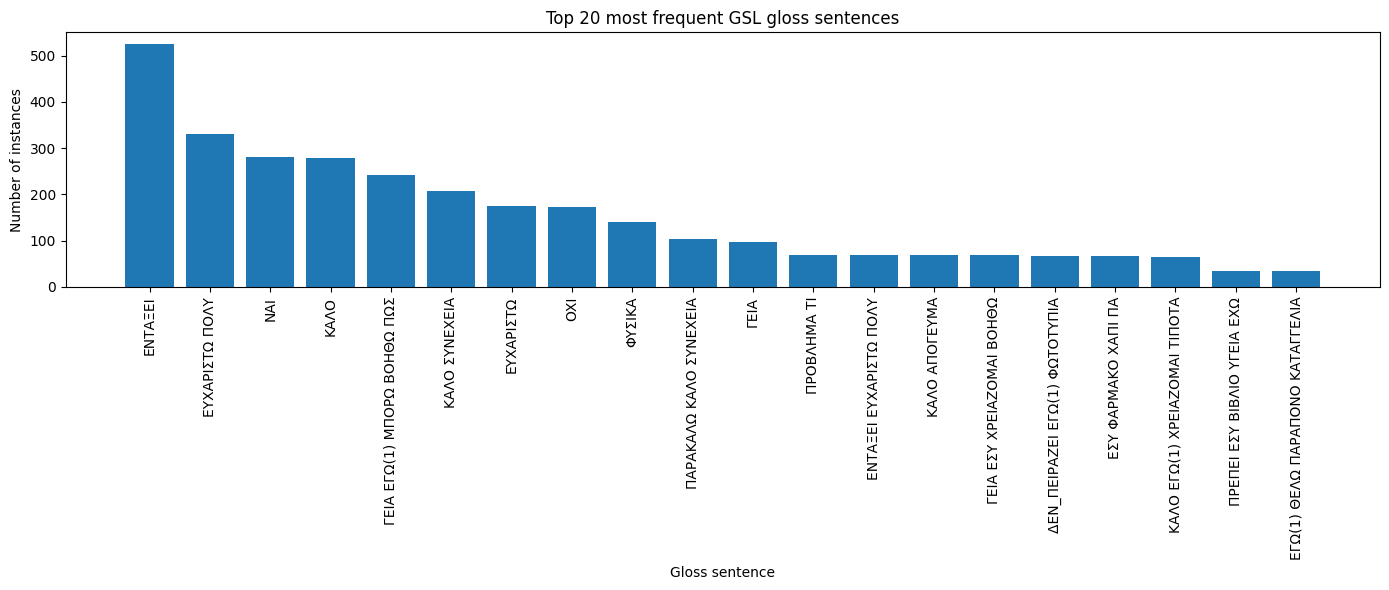

,count
gloss_sentence,
ΕΝΤΑΞΕΙ,524
ΕΥΧΑΡΙΣΤΩ ΠΟΛΥ,330
ΝΑΙ,280
ΚΑΛΟ,279
ΓΕΙΑ ΕΓΩ(1) ΜΠΟΡΩ ΒΟΗΘΩ ΠΩΣ,242
ΚΑΛΟ ΣΥΝΕΧΕΙΑ,208
ΕΥΧΑΡΙΣΤΩ,174
ΟΧΙ,173
ΦΥΣΙΚΑ,140


In [8]:
top_sentences = df[GLOSS_COL].value_counts().head(20)

plt.figure(figsize=(14, 6))
plt.bar(range(len(top_sentences)), top_sentences.values)
plt.xticks(range(len(top_sentences)), top_sentences.index, rotation=90)
plt.title("Top 20 most frequent GSL gloss sentences")
plt.xlabel("Gloss sentence")
plt.ylabel("Number of instances")
plt.tight_layout()
plt.show()

top_sentences

## Cell 9 — Visualization gloss length and most common glosses

This analysis shows:

- how many glosses does usually a sentence has
- which glosses appear more often in the dataset

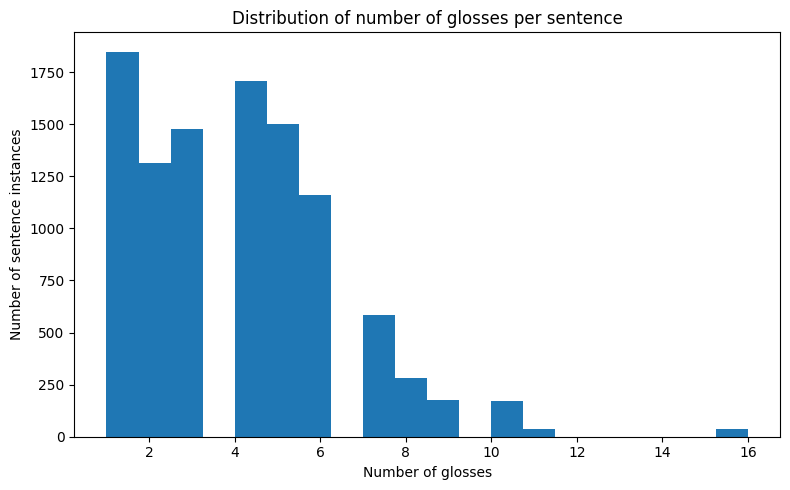

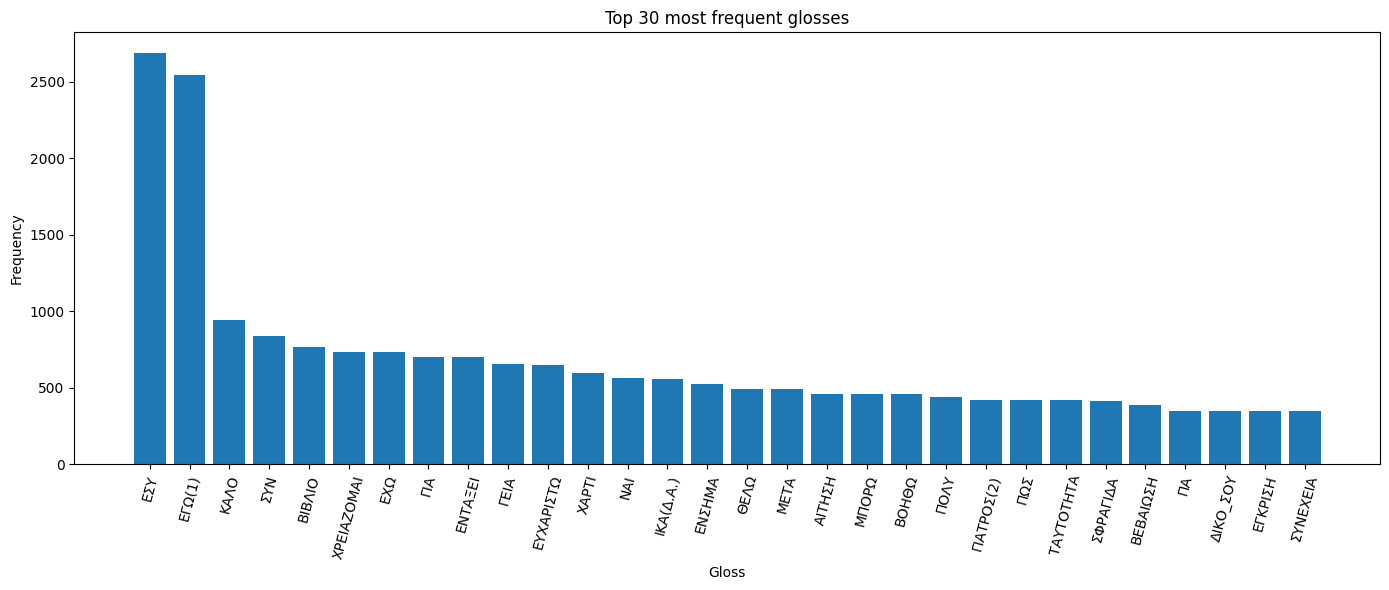

,count
ΕΣΥ,2690
ΕΓΩ(1),2543
ΚΑΛΟ,942
ΣΥΝ,840
ΒΙΒΛΙΟ,768
ΧΡΕΙΑΖΟΜΑΙ,735
ΕΧΩ,735
ΓΙΑ,699
ΕΝΤΑΞΕΙ,698
ΓΕΙΑ,657


In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df["num_glosses"], bins=20)
plt.title("Distribution of number of glosses per sentence")
plt.xlabel("Number of glosses")
plt.ylabel("Number of sentence instances")
plt.tight_layout()
plt.show()

gloss_counts = pd.Series(all_glosses).value_counts().head(30)

plt.figure(figsize=(14, 6))
plt.bar(range(len(gloss_counts)), gloss_counts.values)
plt.xticks(range(len(gloss_counts)), gloss_counts.index, rotation=75)
plt.title("Top 30 most frequent glosses")
plt.xlabel("Gloss")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

gloss_counts.head(10)

## Cell 10 — Analysis per service / signer / repetition

This is helping us to understand from which signers and from which scenarios are the videos coming from.
In a second version, signer-based split could be used (some signers for train and some signers for test).



service distribution:
service
health4    940
kep5       876
kep1       852
health5    805
police2    803
health2    770
kep2       734
kep3       664
kep4       663
police4    630
health3    559
police3    526
police1    525
health1    490
police5    453
Name: count, dtype: int64

signer distribution:
signer
signer4    1474
signer5    1473
signer2    1471
signer7    1470
signer3    1469
signer1    1467
signer6    1466
Name: count, dtype: int64

repetition distribution:
repetition
rep5    2061
rep4    2057
rep2    2052
rep3    2034
rep1    2015
rep6      71
Name: count, dtype: int64

split_file distribution:
split_file
gsl_split_SI_train.csv    8821
gsl_split_SI_test.csv      881
gsl_split_SI_dev.csv       588
Name: count, dtype: int64


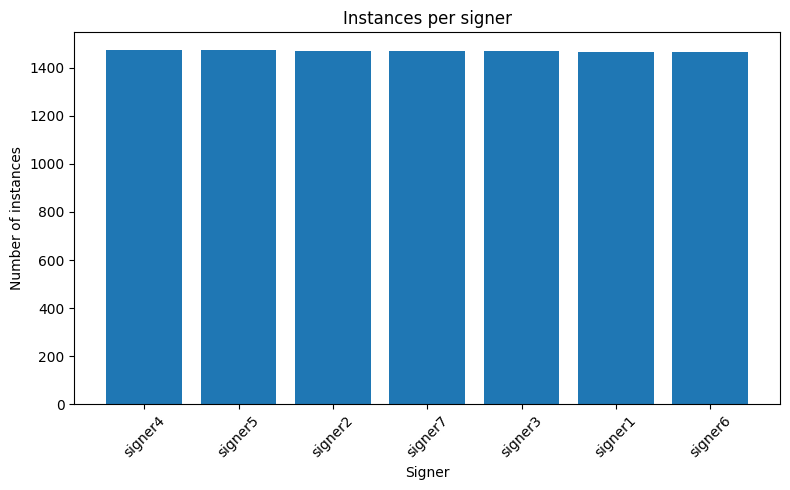

In [10]:
for col in ["service", "signer", "repetition", "split_file"]:
    if col in df.columns:
        print(f"\n{col} distribution:")
        print(df[col].value_counts().head(20))

if "signer" in df.columns:
    signer_counts = df["signer"].value_counts()

    plt.figure(figsize=(8, 5))
    plt.bar(signer_counts.index.astype(str), signer_counts.values)
    plt.title("Instances per signer")
    plt.xlabel("Signer")
    plt.ylabel("Number of instances")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Cell 11 — Select a small subset for Colab

We do not extract the whole dataset. We select a small subset like:

```text
20 classes × 10 samples = περίπου 200 videos
```


In [11]:
MAX_CLASSES = 20
SAMPLES_PER_CLASS = 10

selected_classes = (
    df[TARGET_COL]
    .value_counts()
    .head(MAX_CLASSES)
    .index
)

df_small = df[df[TARGET_COL].isin(selected_classes)].copy()

df_small = (
    df_small
    .groupby(TARGET_COL, group_keys=False)
    .head(SAMPLES_PER_CLASS)
    .reset_index(drop=True)
)

print("Subset shape:", df_small.shape)
print("Selected classes:", df_small[TARGET_COL].nunique())
print(df_small[TARGET_COL].value_counts())

df_small.head()

Subset shape: (200, 9)
Selected classes: 20
gloss_sentence
ΕΓΩ(1) ΘΕΛΩ ΠΑΡΑΠΟΝΟ ΚΑΤΑΓΓΕΛΙΑ    10
ΠΡΟΒΛΗΜΑ ΤΙ                        10
ΕΣΥ ΦΑΡΜΑΚΟ ΧΑΠΙ ΠΑ                10
ΦΥΣΙΚΑ                             10
ΚΑΛΟ                               10
ΕΝΤΑΞΕΙ ΕΥΧΑΡΙΣΤΩ ΠΟΛΥ             10
ΚΑΛΟ ΕΓΩ(1) ΧΡΕΙΑΖΟΜΑΙ ΤΙΠΟΤΑ      10
ΔΕΝ_ΠΕΙΡΑΖΕΙ ΕΓΩ(1) ΦΩΤΟΤΥΠΙΑ      10
ΓΕΙΑ ΕΣΥ ΧΡΕΙΑΖΟΜΑΙ ΒΟΗΘΩ          10
ΠΑΡΑΚΑΛΩ ΚΑΛΟ ΣΥΝΕΧΕΙΑ             10
ΝΑΙ                                10
ΚΑΛΟ ΣΥΝΕΧΕΙΑ                      10
ΓΕΙΑ ΕΓΩ(1) ΜΠΟΡΩ ΒΟΗΘΩ ΠΩΣ        10
ΓΕΙΑ                               10
ΕΥΧΑΡΙΣΤΩ ΠΟΛΥ                     10
ΟΧΙ                                10
ΚΑΛΟ ΑΠΟΓΕΥΜΑ                      10
ΕΥΧΑΡΙΣΤΩ                          10
ΕΝΤΑΞΕΙ                            10
ΠΡΕΠΕΙ ΕΣΥ ΒΙΒΛΙΟ ΥΓΕΙΑ ΕΧΩ        10
Name: count, dtype: int64


,video_key,gloss_sentence,split_file,service,signer,repetition,sentence_file,gloss_list,num_glosses
0,police1_signer3_rep1_sentences/sentences0001,ΕΓΩ(1) ΘΕΛΩ ΠΑΡΑΠΟΝΟ ΚΑΤΑΓΓΕΛΙΑ,gsl_split_SI_dev.csv,police1,signer3,rep1,sentences0001,"[ΕΓΩ(1), ΘΕΛΩ, ΠΑΡΑΠΟΝΟ, ΚΑΤΑΓΓΕΛΙΑ]",4
1,police1_signer3_rep1_sentences/sentences0002,ΠΡΟΒΛΗΜΑ ΤΙ,gsl_split_SI_dev.csv,police1,signer3,rep1,sentences0002,"[ΠΡΟΒΛΗΜΑ, ΤΙ]",2
2,police1_signer3_rep1_sentences/sentences0011,ΕΝΤΑΞΕΙ,gsl_split_SI_dev.csv,police1,signer3,rep1,sentences0011,[ΕΝΤΑΞΕΙ],1
3,police1_signer3_rep1_sentences/sentences0013,ΕΥΧΑΡΙΣΤΩ,gsl_split_SI_dev.csv,police1,signer3,rep1,sentences0013,[ΕΥΧΑΡΙΣΤΩ],1
4,police1_signer3_rep1_sentences/sentences0014,ΚΑΛΟ ΑΠΟΓΕΥΜΑ,gsl_split_SI_dev.csv,police1,signer3,rep1,sentences0014,"[ΚΑΛΟ, ΑΠΟΓΕΥΜΑ]",2


## Cell 12 — Τhe dataset is frame-based



In [16]:
from pathlib import Path, PurePosixPath
import tarfile
import shutil
from tqdm.auto import tqdm

FRAME_EXTENSIONS = {".jpg", ".jpeg", ".png"}

TEMP_FRAME_DIR = Path("/content/gsl_public_service_subset_frames")
TEMP_FRAME_DIR.mkdir(parents=True, exist_ok=True)

print("The continuous dataset contains image frames, not video files.")
print("Temporary frame folder:", TEMP_FRAME_DIR)

The continuous dataset contains image frames, not video files.
Temporary frame folder: /content/gsl_public_service_subset_frames


## Cell 13 — Helper functions for paths inside tar.gz

This cell takes a path from tar, like::

```text
GSL_continuous/health1_signer2_rep1_sentences/sentences0004/frame_0039.jpg
```

and it convert it into video key:

```text
health1_signer2_rep1_sentences/sentences0004
```

in order to match with the CSV's video_key.

In [17]:
def normalize_video_key(x):
    x = str(x).replace("\\", "/").strip()

    for ext in [".mp4", ".avi", ".mov", ".mkv", ".jpg", ".jpeg", ".png"]:
        if x.lower().endswith(ext):
            x = x[:-len(ext)]

    return x


def member_name_to_video_key(member_name):
    """
    Converts tar frame path to the corresponding CSV video_key.

    Example:
    GSL_continuous/health1_signer2_rep1_sentences/sentences0004/frame_0039.jpg
    ->
    health1_signer2_rep1_sentences/sentences0004
    """

    p = PurePosixPath(member_name)

    if p.suffix.lower() not in FRAME_EXTENSIONS:
        return None

    parent = str(p.parent)

    if parent.startswith("GSL_continuous/"):
        parent = parent[len("GSL_continuous/"):]

    return normalize_video_key(parent)


def frame_number(path):
    """
    Extracts the frame number from names like frame_0039.jpg.
    Used for sorting frames in temporal order.
    """
    stem = Path(path).stem
    digits = "".join(ch for ch in stem if ch.isdigit())

    if digits == "":
        return -1

    return int(digits)

## Cell 14 — Extract only subset's frame folders

Here, we extract only the subset's videos and not the whole dataset.

The extracted videos are saved temporaly in:

```text
/content/gsl_public_service_subset_videos
```

If the Colab runtime close, it is not a problem since the processed landmarks will be saved in Drive

In [19]:
#MAX_CLASSES = 5
#SAMPLES_PER_CLASS = 3

# Selected sentence folders from df_small
selected_keys = set(
    df_small["video_key"]
    .astype(str)
    .apply(normalize_video_key)
    .tolist()
)

print("Selected frame folders to extract:", len(selected_keys))

# We do not need all frames. 60 frames are enough for SEQUENCE_LENGTH=60.
MIN_FRAMES_PER_SEQUENCE = 60
MAX_FRAMES_PER_SEQUENCE = 80

frame_counts = {key: 0 for key in selected_keys}

# Optional: clear previous extracted subset
# shutil.rmtree(TEMP_FRAME_DIR, ignore_errors=True)
# TEMP_FRAME_DIR.mkdir(parents=True, exist_ok=True)

with tarfile.open(CONT_TAR, "r|gz") as tar:
    for member in tqdm(tar, desc="Scanning tar.gz"):
        if not member.isfile():
            continue

        key = member_name_to_video_key(member.name)

        if key not in selected_keys:
            continue

        # Stop saving more than MAX_FRAMES_PER_SEQUENCE for the same sentence
        if frame_counts[key] >= MAX_FRAMES_PER_SEQUENCE:
            continue

        file_obj = tar.extractfile(member)

        if file_obj is None:
            continue

        out_dir = TEMP_FRAME_DIR / key
        out_dir.mkdir(parents=True, exist_ok=True)

        frame_name = PurePosixPath(member.name).name
        out_path = out_dir / frame_name

        with open(out_path, "wb") as f:
            shutil.copyfileobj(file_obj, f)

        frame_counts[key] += 1

        # Stop early if all selected folders have enough frames
        if all(count >= MIN_FRAMES_PER_SEQUENCE for count in frame_counts.values()):
            print("All selected sequences have enough frames. Stopping scan.")
            break

print("Extraction summary:")
extracted_ok = 0

for key, count in frame_counts.items():
    if count > 0:
        extracted_ok += 1

print("Folders with extracted frames:", extracted_ok)
print("Total selected folders:", len(selected_keys))

# Show some examples
for key, count in list(frame_counts.items())[:10]:
    print(key, "->", count, "frames")

Selected frame folders to extract: 200


Scanning tar.gz: 0it [00:00, ?it/s]

Extraction summary:
Folders with extracted frames: 200
Total selected folders: 200
kep2_signer3_rep1_sentences/sentences0014 -> 80 frames
health3_signer3_rep2_sentences/sentences0006 -> 21 frames
police2_signer3_rep4_sentences/sentences0022 -> 27 frames
kep1_signer3_rep5_sentences/sentences0011 -> 80 frames
health2_signer3_rep3_sentences/sentences0020 -> 56 frames
police2_signer3_rep2_sentences/sentences0017 -> 33 frames
police3_signer3_rep2_sentences/sentences0011 -> 80 frames
kep1_signer3_rep5_sentences/sentences0001 -> 80 frames
police3_signer3_rep1_sentences/sentences0007 -> 20 frames
kep4_signer3_rep1_sentences/sentences0000 -> 80 frames


## Cell 15 — Connect df_small  wwith the extracted frame folders


In [20]:
def get_extracted_frame_dir(video_key):
    key = normalize_video_key(video_key)
    frame_dir = TEMP_FRAME_DIR / key

    if frame_dir.exists():
        frame_files = list(frame_dir.glob("*.jpg")) + list(frame_dir.glob("*.jpeg")) + list(frame_dir.glob("*.png"))

        if len(frame_files) > 0:
            return frame_dir

    return None


df_small["frame_dir"] = df_small["video_key"].apply(get_extracted_frame_dir)

print(df_small["frame_dir"].notna().value_counts())

df_model = df_small[df_small["frame_dir"].notna()].copy()
df_model["frame_dir"] = df_model["frame_dir"].apply(Path)

print("Final modeling dataset:", df_model.shape)
print("Classes:", df_model["gloss_sentence"].nunique())

df_model[["video_key", "frame_dir", "gloss_sentence"]].head()

frame_dir
True    200
Name: count, dtype: int64
Final modeling dataset: (200, 10)
Classes: 20


,video_key,frame_dir,gloss_sentence
0,police1_signer3_rep1_sentences/sentences0001,/content/gsl_public_service_subset_frames/poli...,ΕΓΩ(1) ΘΕΛΩ ΠΑΡΑΠΟΝΟ ΚΑΤΑΓΓΕΛΙΑ
1,police1_signer3_rep1_sentences/sentences0002,/content/gsl_public_service_subset_frames/poli...,ΠΡΟΒΛΗΜΑ ΤΙ
2,police1_signer3_rep1_sentences/sentences0011,/content/gsl_public_service_subset_frames/poli...,ΕΝΤΑΞΕΙ
3,police1_signer3_rep1_sentences/sentences0013,/content/gsl_public_service_subset_frames/poli...,ΕΥΧΑΡΙΣΤΩ
4,police1_signer3_rep1_sentences/sentences0014,/content/gsl_public_service_subset_frames/poli...,ΚΑΛΟ ΑΠΟΓΕΥΜΑ


## Cell 16 — Check one extracted sentence folder


In [21]:
sample_dir = df_model["frame_dir"].iloc[0]

frame_files = (
    list(sample_dir.glob("*.jpg")) +
    list(sample_dir.glob("*.jpeg")) +
    list(sample_dir.glob("*.png"))
)

frame_files = sorted(frame_files, key=frame_number)

print("Sample frame folder:", sample_dir)
print("Number of frames:", len(frame_files))
print("First 5 frames:")
for f in frame_files[:5]:
    print(f)

Sample frame folder: /content/gsl_public_service_subset_frames/police1_signer3_rep1_sentences/sentences0001
Number of frames: 80
First 5 frames:
/content/gsl_public_service_subset_frames/police1_signer3_rep1_sentences/sentences0001/frame_0000.jpg
/content/gsl_public_service_subset_frames/police1_signer3_rep1_sentences/sentences0001/frame_0001.jpg
/content/gsl_public_service_subset_frames/police1_signer3_rep1_sentences/sentences0001/frame_0002.jpg
/content/gsl_public_service_subset_frames/police1_signer3_rep1_sentences/sentences0001/frame_0003.jpg
/content/gsl_public_service_subset_frames/police1_signer3_rep1_sentences/sentences0001/frame_0005.jpg


## Cell 17 — MediaPipe feature extraction from frame folder

In [22]:
import mediapipe as mp
import numpy as np

mp_holistic = mp.solutions.holistic

SEQUENCE_LENGTH = 60
FEATURE_MODE = "hands_pose"  # "hands_only" or "hands_pose"


def landmarks_to_array(landmarks, n_landmarks, dims):
    if landmarks is None:
        return np.zeros(n_landmarks * dims, dtype=np.float32)

    arr = []

    for lm in landmarks.landmark:
        values = [lm.x, lm.y, lm.z]

        if dims == 4:
            values.append(lm.visibility)

        arr.extend(values)

    return np.array(arr, dtype=np.float32)


def extract_keypoints_from_results(results, feature_mode="hands_pose"):
    left_hand = landmarks_to_array(results.left_hand_landmarks, 21, 3)
    right_hand = landmarks_to_array(results.right_hand_landmarks, 21, 3)

    if feature_mode == "hands_only":
        return np.concatenate([left_hand, right_hand])

    if feature_mode == "hands_pose":
        pose = landmarks_to_array(results.pose_landmarks, 33, 4)
        return np.concatenate([left_hand, right_hand, pose])

    raise ValueError(f"Unknown feature_mode: {feature_mode}")


def get_sorted_frame_files(frame_dir):
    frame_dir = Path(frame_dir)

    files = (
        list(frame_dir.glob("*.jpg")) +
        list(frame_dir.glob("*.jpeg")) +
        list(frame_dir.glob("*.png"))
    )

    return sorted(files, key=frame_number)


def sample_frame_indices(total_frames, sequence_length):
    if total_frames <= 0:
        return list(range(sequence_length))

    if total_frames >= sequence_length:
        return np.linspace(0, total_frames - 1, sequence_length).astype(int).tolist()

    indices = list(range(total_frames))

    while len(indices) < sequence_length:
        indices.append(total_frames - 1)

    return indices[:sequence_length]


def extract_frame_folder_features(frame_dir, sequence_length=60, feature_mode="hands_pose", resize_width=640):
    frame_files = get_sorted_frame_files(frame_dir)

    if len(frame_files) == 0:
        raise RuntimeError(f"No frames found in folder: {frame_dir}")

    frame_indices = sample_frame_indices(len(frame_files), sequence_length)

    sequence = []

    with mp_holistic.Holistic(
        static_image_mode=True,
        model_complexity=1,
        smooth_landmarks=False,
        enable_segmentation=False,
        refine_face_landmarks=False,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic:

        for idx in frame_indices:
            frame_path = frame_files[idx]

            frame = cv2.imread(str(frame_path))

            if frame is None:
                dim = 126 if feature_mode == "hands_only" else 258
                sequence.append(np.zeros(dim, dtype=np.float32))
                continue

            if resize_width is not None:
                h, w = frame.shape[:2]
                scale = resize_width / w
                frame = cv2.resize(frame, (resize_width, int(h * scale)))

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(rgb)

            keypoints = extract_keypoints_from_results(results, feature_mode)
            sequence.append(keypoints)

    return np.array(sequence, dtype=np.float32)


# Test on one folder
sample_features = extract_frame_folder_features(
    df_model["frame_dir"].iloc[0],
    sequence_length=SEQUENCE_LENGTH,
    feature_mode=FEATURE_MODE
)

print("Sample feature shape:", sample_features.shape)

Sample feature shape: (60, 258)


## Cell 18 — Extract landmarks for all the selected frame folders

In [23]:
X_PATH = PROCESSED_DIR / f"X_FRAMES_{FEATURE_MODE}_{SEQUENCE_LENGTH}_{MAX_CLASSES}classes_{SAMPLES_PER_CLASS}samples.npy"
Y_PATH = PROCESSED_DIR / f"y_text_FRAMES_{FEATURE_MODE}_{SEQUENCE_LENGTH}_{MAX_CLASSES}classes_{SAMPLES_PER_CLASS}samples.npy"
META_PATH = PROCESSED_DIR / f"metadata_FRAMES_{FEATURE_MODE}_{SEQUENCE_LENGTH}_{MAX_CLASSES}classes_{SAMPLES_PER_CLASS}samples.csv"

if X_PATH.exists() and Y_PATH.exists() and META_PATH.exists():
    print("Loading existing processed frame features from Drive...")

    X = np.load(X_PATH)
    y_text = np.load(Y_PATH, allow_pickle=True)
    metadata = pd.read_csv(META_PATH)

else:
    print("Extracting MediaPipe features from frame folders...")

    X_list = []
    y_list = []
    rows = []

    for _, row in tqdm(df_model.iterrows(), total=len(df_model)):
        frame_dir = row["frame_dir"]
        label = row["gloss_sentence"]

        try:
            features = extract_frame_folder_features(
                frame_dir,
                sequence_length=SEQUENCE_LENGTH,
                feature_mode=FEATURE_MODE
            )

            X_list.append(features)
            y_list.append(str(label))

            rows.append({
                "video_key": row["video_key"],
                "frame_dir": str(frame_dir),
                "gloss_sentence": row["gloss_sentence"],
                "service": row.get("service", ""),
                "signer": row.get("signer", ""),
                "repetition": row.get("repetition", "")
            })

        except Exception as e:
            print("Failed frame folder:", frame_dir)
            print("Error:", e)

    X = np.stack(X_list, axis=0)
    y_text = np.array(y_list)
    metadata = pd.DataFrame(rows)

    np.save(X_PATH, X)
    np.save(Y_PATH, y_text)
    metadata.to_csv(META_PATH, index=False, encoding="utf-8-sig")

print("X shape:", X.shape)
print("y_text shape:", y_text.shape)
print("Metadata shape:", metadata.shape)

Extracting MediaPipe features from frame folders...


  0%|          | 0/200 [00:00<?, ?it/s]

X shape: (200, 60, 258)
y_text shape: (200,)
Metadata shape: (200, 6)


In [24]:
import pandas as pd

frame_summary = pd.DataFrame({
    "video_key": list(frame_counts.keys()),
    "num_extracted_frames": list(frame_counts.values())
})

print("Total selected folders:", len(frame_summary))
print("Folders with frames:", (frame_summary["num_extracted_frames"] > 0).sum())
print("Folders with at least 60 frames:", (frame_summary["num_extracted_frames"] >= 60).sum())
print("Folders with fewer than 60 frames:", (frame_summary["num_extracted_frames"] < 60).sum())

frame_summary.sort_values("num_extracted_frames").head(20)

Total selected folders: 200
Folders with frames: 200
Folders with at least 60 frames: 90
Folders with fewer than 60 frames: 110


,video_key,num_extracted_frames
129,kep3_signer3_rep2_sentences/sentences0015,13
74,health4_signer3_rep1_sentences/sentences0025,13
90,health3_signer3_rep1_sentences/sentences0008,14
92,health4_signer3_rep2_sentences/sentences0025,14
156,kep1_signer3_rep3_sentences/sentences0000,14
124,police4_signer3_rep2_sentences/sentences0015,14
149,kep5_signer3_rep2_sentences/sentences0017,14
160,kep1_signer3_rep2_sentences/sentences0008,14
175,kep1_signer3_rep2_sentences/sentences0000,15
179,police1_signer3_rep1_sentences/sentences0011,15


Some sentence folders contain fewer than 60 frames. This is handled during preprocessing by repeating the last available frame until each sample has a fixed sequence length of 60 frames. This allows all samples to have the same input shape for the neural network.

In [26]:
# Manual mapping from GSL gloss sentence to natural Greek meaning.
# For now, only some examples are manually translated.
# If a gloss sentence is not in the dictionary, we keep the gloss sentence itself.

NATURAL_GREEK_MAP = {
    "ΓΕΙΑ ΕΓΩ(1) ΜΠΟΡΩ ΒΟΗΘΩ": "Γεια σας, μπορώ να σας βοηθήσω.",
}

def gloss_to_natural_greek(gloss_sentence):
    return NATURAL_GREEK_MAP.get(str(gloss_sentence), str(gloss_sentence))


# Add natural_greek column to metadata if it does not already exist.
if "natural_greek" not in metadata.columns:
    metadata["natural_greek"] = metadata["gloss_sentence"].apply(gloss_to_natural_greek)

print(metadata.columns)
metadata[["gloss_sentence", "natural_greek"]].drop_duplicates().head(20)

Index(['video_key', 'frame_dir', 'gloss_sentence', 'service', 'signer',
       'repetition', 'natural_greek'],
      dtype='object')


,gloss_sentence,natural_greek
0,ΕΓΩ(1) ΘΕΛΩ ΠΑΡΑΠΟΝΟ ΚΑΤΑΓΓΕΛΙΑ,ΕΓΩ(1) ΘΕΛΩ ΠΑΡΑΠΟΝΟ ΚΑΤΑΓΓΕΛΙΑ
1,ΠΡΟΒΛΗΜΑ ΤΙ,ΠΡΟΒΛΗΜΑ ΤΙ
2,ΕΝΤΑΞΕΙ,ΕΝΤΑΞΕΙ
3,ΕΥΧΑΡΙΣΤΩ,ΕΥΧΑΡΙΣΤΩ
4,ΚΑΛΟ ΑΠΟΓΕΥΜΑ,ΚΑΛΟ ΑΠΟΓΕΥΜΑ
10,ΟΧΙ,ΟΧΙ
12,ΕΥΧΑΡΙΣΤΩ ΠΟΛΥ,ΕΥΧΑΡΙΣΤΩ ΠΟΛΥ
13,ΓΕΙΑ,ΓΕΙΑ
18,ΓΕΙΑ ΕΓΩ(1) ΜΠΟΡΩ ΒΟΗΘΩ ΠΩΣ,ΓΕΙΑ ΕΓΩ(1) ΜΠΟΡΩ ΒΟΗΘΩ ΠΩΣ
22,ΚΑΛΟ ΣΥΝΕΧΕΙΑ,ΚΑΛΟ ΣΥΝΕΧΕΙΑ


## Cell 19 — Label encoding και train/validation/test split

Τhe labels are text, like:

```text
ΓΕΙΑ ΕΓΩ(1) ΜΠΟΡΩ ΒΟΗΘΩ
```

We convert them into numbers with `LabelEncoder`.

Then, we split into:

- train set
- validation set
- test set

In [27]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import joblib
import json
import numpy as np
import pandas as pd

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)

ENCODER_PATH = MODELS_DIR / "label_encoder.pkl"
joblib.dump(label_encoder, ENCODER_PATH)

# Save natural Greek mapping for Streamlit app.
natural_map = (
    metadata[["gloss_sentence", "natural_greek"]]
    .drop_duplicates()
    .set_index("gloss_sentence")["natural_greek"]
    .to_dict()
)

with open(MODELS_DIR / "natural_greek_map.json", "w", encoding="utf-8") as f:
    json.dump(natural_map, f, ensure_ascii=False, indent=2)

print("Saved label encoder to:", ENCODER_PATH)
print("Saved natural Greek map to:", MODELS_DIR / "natural_greek_map.json")

# Train / validation / test split
class_counts = pd.Series(y).value_counts()
stratify_arg = y if class_counts.min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=stratify_arg
)

train_class_counts = pd.Series(y_train).value_counts()
stratify_val = y_train if train_class_counts.min() >= 2 else None

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=SEED,
    stratify=stratify_val
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Number of classes: 20
Saved label encoder to: /content/drive/MyDrive/GSL_public_service_outputs/models/label_encoder.pkl
Saved natural Greek map to: /content/drive/MyDrive/GSL_public_service_outputs/models/natural_greek_map.json
Train: (136, 60, 258)
Validation: (24, 60, 258)
Test: (40, 60, 258)


## Cell 20 — Normalization of characteristics

We calculate mean and standard deviation only from the train set.
After, we use the same statistics for validation, test and Streamlit inference.

In [28]:
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True)

std[std < 1e-6] = 1.0

X_train_n = (X_train - mean) / std
X_val_n = (X_val - mean) / std
X_test_n = (X_test - mean) / std

NORM_PATH = MODELS_DIR / "normalization_stats.npz"
np.savez_compressed(NORM_PATH, mean=mean, std=std)

print("Normalization stats saved to:", NORM_PATH)

Normalization stats saved to: /content/drive/MyDrive/GSL_public_service_outputs/models/normalization_stats.npz


## Cell 21 — Create model GRU / LSTM / Transformer

For the first version, `GRU` is recommended because it is lighter than Transformer and suitable for sequence data.

We can change:

```python
MODEL_TYPE = "gru"
```

into:

```python
MODEL_TYPE = "lstm"
```

or:

```python
MODEL_TYPE = "transformer"
```

In [29]:
MODEL_TYPE = "gru"  # "gru", "lstm", or "transformer"


def build_gru_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Bidirectional(layers.GRU(96, return_sequences=True)),
        layers.Dropout(0.30),
        layers.Bidirectional(layers.GRU(64)),
        layers.Dropout(0.30),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model


def build_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Bidirectional(layers.LSTM(96, return_sequences=True)),
        layers.Dropout(0.30),
        layers.Bidirectional(layers.LSTM(64)),
        layers.Dropout(0.30),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model


def build_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Dense(128)(inputs)

    attn = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = layers.LayerNormalization()(x + attn)

    ff = layers.Dense(256, activation="relu")(x)
    ff = layers.Dense(128)(ff)
    x = layers.LayerNormalization()(x + ff)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs)


input_shape = X_train_n.shape[1:]

if MODEL_TYPE == "gru":
    model = build_gru_model(input_shape, num_classes)
elif MODEL_TYPE == "lstm":
    model = build_lstm_model(input_shape, num_classes)
elif MODEL_TYPE == "transformer":
    model = build_transformer_model(input_shape, num_classes)
else:
    raise ValueError("MODEL_TYPE must be 'gru', 'lstm', or 'transformer'.")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=min(5, num_classes), name="top_k_accuracy")
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 192)        │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 192)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,220 (1.23 MB)

 Trainable params: 323,220 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

## Cell 22 — Train model

We use:

- `ModelCheckpoint` to save the best model
- `EarlyStopping` to avoid overtraining
- `ReduceLROnPlateau` for better convergence

In [30]:
MODEL_PATH = MODELS_DIR / f"gsl_public_service_{MODEL_TYPE}_{FEATURE_MODE}_{SEQUENCE_LENGTH}.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=5,
        factor=0.5,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train_n,
    y_train,
    validation_data=(X_val_n, y_val),
    epochs=50,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

print("Best model saved to:", MODEL_PATH)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.0827 - loss: 2.9755 - top_k_accuracy: 0.3834
Epoch 1: val_accuracy improved from -inf to 0.29167, saving model to /content/drive/MyDrive/GSL_public_service_outputs/models/gsl_public_service_gru_hands_pose_60.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 273ms/step - accuracy: 0.0847 - loss: 2.9665 - top_k_accuracy: 0.3892 - val_accuracy: 0.2917 - val_loss: 2.2894 - val_top_k_accuracy: 0.7500 - learning_rate: 0.0010
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.4435 - loss: 2.0193 - top_k_accuracy: 0.8391
Epoch 2: val_accuracy improved from 0.29167 to 0.70833, saving model to /content/drive/MyDrive/GSL_public_service_outputs/models/gsl_public_service_gru_hands_pose_60.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - accuracy: 0.4433 - loss: 2.0199 - top_k_accuracy: 0.8412 - val_accuracy: 0.7083 - val_loss: 1.6918 - val_top_k_accuracy: 1.0000 - learning_rate: 0.0010
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - ac

## Cell 23 — Visualization of training curves

We can see:

- training accuracy
- validation accuracy
- training loss
- validation loss


If the train accuracy increases a lot but the validation accuracy remains low, then we have overfitting.

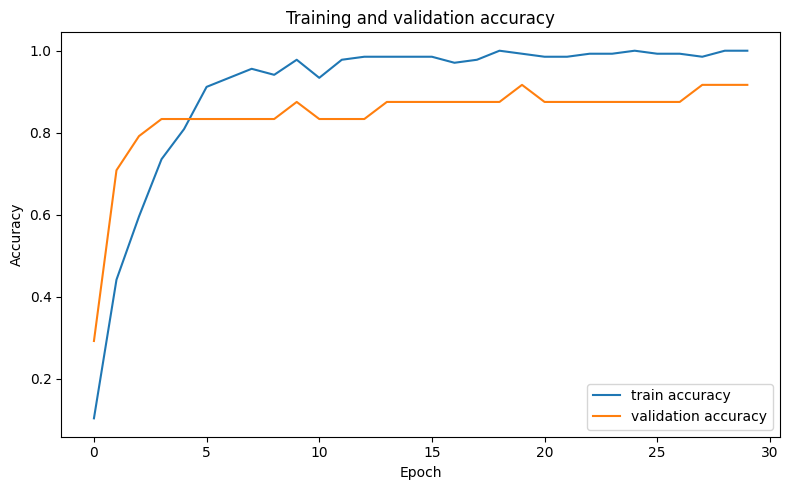

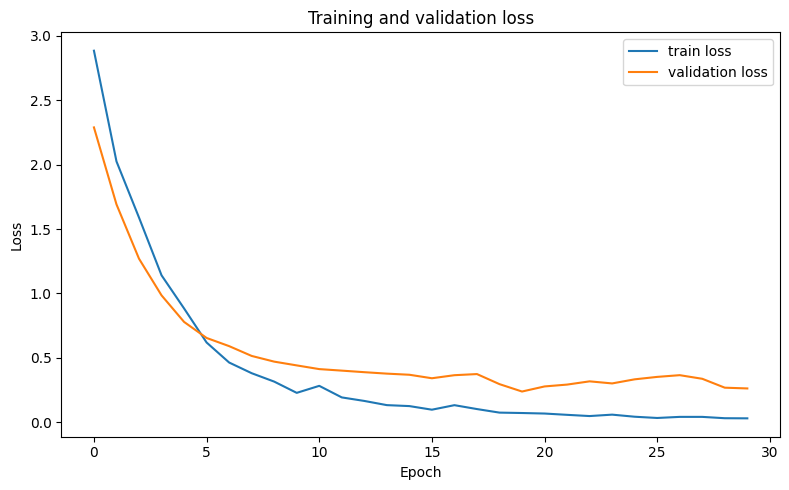

In [31]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(REPORTS_DIR / "training_history.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="train accuracy")
plt.plot(history_df["val_accuracy"], label="validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "accuracy_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="train loss")
plt.plot(history_df["val_loss"], label="validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "loss_curve.png", dpi=200)
plt.show()

## Cell 24 — Evaluation of test set

We calculate:

- accuracy
- top-k accuracy
- classification report
- predictions for confusion matrix

In [32]:
best_model = tf.keras.models.load_model(MODEL_PATH)

test_probs = best_model.predict(X_test_n)
test_preds = np.argmax(test_probs, axis=1)

test_acc = accuracy_score(y_test, test_preds)
print("Test accuracy:", round(test_acc, 4))

if num_classes > 1:
    k = min(5, num_classes)
    test_topk = top_k_accuracy_score(y_test, test_probs, k=k, labels=np.arange(num_classes))
    print(f"Test top-{k} accuracy:", round(test_topk, 4))

report = classification_report(
    y_test,
    test_preds,
    target_names=label_encoder.classes_,
    zero_division=0
)

print(report)

with open(REPORTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(f"Model type: {MODEL_TYPE}\n")
    f.write(f"Feature mode: {FEATURE_MODE}\n")
    f.write(f"Sequence length: {SEQUENCE_LENGTH}\n")
    f.write(f"Test accuracy: {test_acc:.4f}\n")
    if num_classes > 1:
        f.write(f"Test top-{k} accuracy: {test_topk:.4f}\n")
    f.write("\n")
    f.write(report)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step
Test accuracy: 0.975
Test top-5 accuracy: 1.0
                                 precision    recall  f1-score   support

                           ΓΕΙΑ       1.00      1.00      1.00         2
    ΓΕΙΑ ΕΓΩ(1) ΜΠΟΡΩ ΒΟΗΘΩ ΠΩΣ       1.00      1.00      1.00         2
      ΓΕΙΑ ΕΣΥ ΧΡΕΙΑΖΟΜΑΙ ΒΟΗΘΩ       1.00      1.00      1.00         2
  ΔΕΝ_ΠΕΙΡΑΖΕΙ ΕΓΩ(1) ΦΩΤΟΤΥΠΙΑ       1.00      1.00      1.00         2
ΕΓΩ(1) ΘΕΛΩ ΠΑΡΑΠΟΝΟ ΚΑΤΑΓΓΕΛΙΑ       1.00      1.00      1.00         2
                        ΕΝΤΑΞΕΙ       1.00      1.00      1.00         2
         ΕΝΤΑΞΕΙ ΕΥΧΑΡΙΣΤΩ ΠΟΛΥ       1.00      1.00      1.00         2
            ΕΣΥ ΦΑΡΜΑΚΟ ΧΑΠΙ ΠΑ       1.00      1.00      1.00         2
                      ΕΥΧΑΡΙΣΤΩ       1.00      1.00      1.00         2
                 ΕΥΧΑΡΙΣΤΩ ΠΟΛΥ       1.00      1.00      1.00         2
                           ΚΑΛΟ       1.00      0.50      0.67         2
                  ΚΑΛΟ ΑΠΟΓΕΥΜΑ       

## Cell 25 — Confusion matrix

Τhe confusion matrix shows which sentences the model confuses.

For 20 classes, it is still relatively readable.

<Figure size 1400x1200 with 0 Axes>

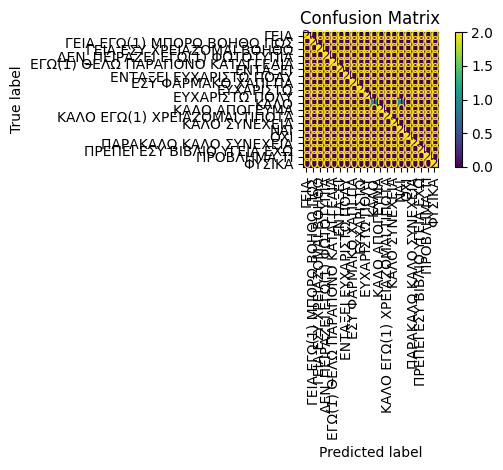

In [33]:
cm = confusion_matrix(y_test, test_preds, labels=np.arange(num_classes))

plt.figure(figsize=(14, 12))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(xticks_rotation=90, values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "confusion_matrix.png", dpi=200)
plt.show()

## Cell 26 — Error analysis

Here, we create a table with the model's errors.
For each error, we keep:

- true label
- predicted label
- confidence

In [34]:
errors = []

for i, (true_id, pred_id) in enumerate(zip(y_test, test_preds)):
    if true_id != pred_id:
        confidence = float(np.max(test_probs[i]))

        errors.append({
            "true_gloss_sentence": label_encoder.inverse_transform([true_id])[0],
            "predicted_gloss_sentence": label_encoder.inverse_transform([pred_id])[0],
            "confidence": confidence
        })

errors_df = pd.DataFrame(errors)
errors_df.to_csv(REPORTS_DIR / "error_analysis.csv", index=False, encoding="utf-8-sig")

print("Number of errors:", len(errors_df))
errors_df.head(20)

Number of errors: 1


,true_gloss_sentence,predicted_gloss_sentence,confidence
0,ΚΑΛΟ,ΝΑΙ,0.522848


## Cell 27 — New video prediction function

This function takes a video and returns the top-k possible suggestions.

In [37]:
def predict_video(video_path, top_k=5):
    model = tf.keras.models.load_model(MODEL_PATH)
    encoder = joblib.load(ENCODER_PATH)

    norm = np.load(NORM_PATH)
    mean = norm["mean"]
    std = norm["std"]

    features = extract_video_features(
        video_path,
        sequence_length=SEQUENCE_LENGTH,
        feature_mode=FEATURE_MODE
    )

    X_one = features.reshape(1, SEQUENCE_LENGTH, -1)
    X_one = (X_one - mean) / std

    probs = model.predict(X_one, verbose=0)[0]
    top_indices = np.argsort(probs)[::-1][:top_k]

    results = []

    for idx in top_indices:
        gloss = encoder.inverse_transform([idx])[0]
        results.append({
            "gloss_sentence": gloss,
            "natural_greek": gloss_to_natural_greek(gloss),
            "confidence": float(probs[idx])
        })

    return pd.DataFrame(results)


# Example:
# predict_video(df_model["video_full_path"].iloc[0], top_k=5)

## Cell 28 — Export configuration for Streamlit

The Streamlit application needs to know:

- which model to load
- which label encoder to load
- which normalization statistics to use
- which sequence length was used
- which feature mode was used

In [38]:
APP_CONFIG = {
    "model_path": str(MODEL_PATH),
    "encoder_path": str(ENCODER_PATH),
    "normalization_path": str(NORM_PATH),
    "natural_greek_map_path": str(MODELS_DIR / "natural_greek_map.json"),
    "sequence_length": SEQUENCE_LENGTH,
    "feature_mode": FEATURE_MODE,
    "model_type": MODEL_TYPE,
    "description": "Greek Sign Language public-service sentence recognition"
}

APP_CONFIG_PATH = MODELS_DIR / "app_config.json"

with open(APP_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(APP_CONFIG, f, ensure_ascii=False, indent=2)

print("App config saved to:", APP_CONFIG_PATH)
print(json.dumps(APP_CONFIG, ensure_ascii=False, indent=2))

App config saved to: /content/drive/MyDrive/GSL_public_service_outputs/models/app_config.json
{
  "model_path": "/content/drive/MyDrive/GSL_public_service_outputs/models/gsl_public_service_gru_hands_pose_60.keras",
  "encoder_path": "/content/drive/MyDrive/GSL_public_service_outputs/models/label_encoder.pkl",
  "normalization_path": "/content/drive/MyDrive/GSL_public_service_outputs/models/normalization_stats.npz",
  "natural_greek_map_path": "/content/drive/MyDrive/GSL_public_service_outputs/models/natural_greek_map.json",
  "sequence_length": 60,
  "feature_mode": "hands_pose",
  "model_type": "gru",
  "description": "Greek Sign Language public-service sentence recognition"
}


## Cell 29 — Create Streamlit App

This cell writes a file:

```text
streamlit_app.py
```

The application allows the public service employee to upload videos and get a preview.

In [60]:
%%writefile streamlit_app.py
import json
import tempfile
from pathlib import Path

import cv2
import joblib
import mediapipe as mp
import numpy as np
import pandas as pd
import streamlit as st
import tensorflow as tf


st.set_page_config(
    page_title="GSL Public Service Assistant",
    page_icon="🤟",
    layout="wide",
    initial_sidebar_state="expanded"
)

DEFAULT_CONFIG_PATH = Path("/content/drive/MyDrive/GSL_public_service_outputs/models/app_config.json")

mp_holistic = mp.solutions.holistic


# ============================================================
# Feature extraction
# ============================================================

def landmarks_to_array(landmarks, n_landmarks, dims):
    if landmarks is None:
        return np.zeros(n_landmarks * dims, dtype=np.float32)

    arr = []
    for lm in landmarks.landmark:
        values = [lm.x, lm.y, lm.z]
        if dims == 4:
            values.append(lm.visibility)
        arr.extend(values)

    return np.array(arr, dtype=np.float32)


def extract_keypoints_from_results(results, feature_mode="hands_pose"):
    left_hand = landmarks_to_array(results.left_hand_landmarks, 21, 3)
    right_hand = landmarks_to_array(results.right_hand_landmarks, 21, 3)

    if feature_mode == "hands_only":
        return np.concatenate([left_hand, right_hand])

    if feature_mode == "hands_pose":
        pose = landmarks_to_array(results.pose_landmarks, 33, 4)
        return np.concatenate([left_hand, right_hand, pose])

    raise ValueError(f"Unknown feature_mode: {feature_mode}")


def sample_frame_indices(total_frames, sequence_length):
    if total_frames <= 0:
        return list(range(sequence_length))

    if total_frames >= sequence_length:
        return np.linspace(0, total_frames - 1, sequence_length).astype(int).tolist()

    indices = list(range(total_frames))
    while len(indices) < sequence_length:
        indices.append(total_frames - 1)

    return indices[:sequence_length]


def extract_video_features(video_path, sequence_length=60, feature_mode="hands_pose", resize_width=640):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError("Could not open the uploaded video.")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = sample_frame_indices(total_frames, sequence_length)

    sequence = []

    with mp_holistic.Holistic(
        static_image_mode=False,
        model_complexity=1,
        smooth_landmarks=True,
        enable_segmentation=False,
        refine_face_landmarks=False,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic:

        for frame_idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ok, frame = cap.read()

            if not ok:
                dim = 126 if feature_mode == "hands_only" else 258
                sequence.append(np.zeros(dim, dtype=np.float32))
                continue

            if resize_width is not None:
                h, w = frame.shape[:2]
                scale = resize_width / w
                frame = cv2.resize(frame, (resize_width, int(h * scale)))

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(rgb)

            keypoints = extract_keypoints_from_results(results, feature_mode)
            sequence.append(keypoints)

    cap.release()
    return np.array(sequence, dtype=np.float32)


# ============================================================
# Load model
# ============================================================

@st.cache_resource
def load_resources(config_path):
    config_path = Path(config_path)

    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)

    model = tf.keras.models.load_model(config["model_path"])
    encoder = joblib.load(config["encoder_path"])

    norm = np.load(config["normalization_path"])
    mean = norm["mean"]
    std = norm["std"]

    natural_map_path = Path(config.get("natural_greek_map_path", ""))
    if natural_map_path.exists():
        with open(natural_map_path, "r", encoding="utf-8") as f:
            natural_map = json.load(f)
    else:
        natural_map = {}

    return config, model, encoder, mean, std, natural_map


def predict_video(video_path, config, model, encoder, mean, std, natural_map, top_k=5):
    sequence_length = int(config["sequence_length"])
    feature_mode = config["feature_mode"]

    features = extract_video_features(
        video_path,
        sequence_length=sequence_length,
        feature_mode=feature_mode
    )

    X = features.reshape(1, sequence_length, -1)
    X = (X - mean) / std

    probs = model.predict(X, verbose=0)[0]
    top_indices = np.argsort(probs)[::-1][:top_k]

    rows = []
    for idx in top_indices:
        gloss = encoder.inverse_transform([idx])[0]
        rows.append({
            "GSL gloss sentence": gloss,
            "Natural Greek meaning": natural_map.get(gloss, gloss),
            "Confidence": float(probs[idx])
        })

    return pd.DataFrame(rows)


# ============================================================
# Sidebar
# ============================================================

st.sidebar.title("⚙️ Settings")

config_path = st.sidebar.text_input(
    "Model config path",
    value=str(DEFAULT_CONFIG_PATH)
)

top_k = st.sidebar.slider(
    "Top predictions",
    min_value=1,
    max_value=10,
    value=5
)

confidence_threshold = st.sidebar.slider(
    "Minimum confidence threshold",
    min_value=0.0,
    max_value=1.0,
    value=0.60,
    step=0.05
)

service_context = st.sidebar.selectbox(
    "Public-service scenario",
    [
        "Citizen Service Center",
        "Police / Public Safety",
        "Municipality",
        "Hospital / Health Service",
        "School Office",
        "Other Public Service"
    ]
)

st.sidebar.markdown("---")
st.sidebar.info(
    "This app works only for the predefined GSL sentence classes included in the trained model."
)


# ============================================================
# Main page
# ============================================================

st.title("🤟 Greek Sign Language Public-Service Assistant")

st.markdown(
    """
This application recognizes **predefined Greek Sign Language sentence inputs** related to public-service communication.

It is designed as a **closed-domain assistant** for scenarios such as citizen service centers, police services,
municipal offices, hospitals and school offices.

It is **not** a general sign language translator and does not replace a professional interpreter.
"""
)

try:
    config, model, encoder, mean, std, natural_map = load_resources(config_path)
    st.success("✅ Model loaded successfully.")
except Exception as e:
    st.error(f"❌ Could not load model/config: {e}")
    st.stop()


with st.expander("ℹ️ How to use this app", expanded=True):
    st.markdown(
        """
1. Upload a short video containing one GSL public-service sentence.
2. Press **Recognize sentence**.
3. The app will show:
   - the predicted GSL gloss sentence,
   - the possible natural Greek meaning,
   - the confidence score,
   - the top alternative predictions,
   - a suggested response for the public-service employee.

For best results, the signer should be clearly visible, with good lighting and visible hands.
"""
    )


col1, col2 = st.columns([1.05, 1])

with col1:
    st.subheader("📤 Upload GSL input")

    uploaded_file = st.file_uploader(
        "Upload a short Greek Sign Language video",
        type=["mp4", "avi", "mov", "mkv"]
    )

    if uploaded_file is not None:
        suffix = Path(uploaded_file.name).suffix

        with tempfile.NamedTemporaryFile(delete=False, suffix=suffix) as tmp:
            tmp.write(uploaded_file.read())
            temp_video_path = tmp.name

        st.video(temp_video_path)

        recognize = st.button("🔍 Recognize sentence", use_container_width=True)

        if recognize:
            with st.spinner("Processing video with MediaPipe and running prediction..."):
                try:
                    results = predict_video(
                        temp_video_path,
                        config,
                        model,
                        encoder,
                        mean,
                        std,
                        natural_map,
                        top_k=top_k
                    )

                    st.session_state["results"] = results

                except Exception as e:
                    st.error(f"Prediction failed: {e}")


with col2:
    st.subheader("📌 Recognition result")

    if "results" not in st.session_state:
        st.info("Upload a video and press **Recognize sentence**.")
    else:
        results = st.session_state["results"]
        best = results.iloc[0]
        confidence = float(best["Confidence"])

        if confidence >= confidence_threshold:
            st.success("High-confidence prediction")
        else:
            st.warning(
                "Low-confidence prediction. The result may be unreliable. "
                "Try uploading a clearer video."
            )

        st.markdown("### Predicted GSL gloss sentence")
        st.code(best["GSL gloss sentence"], language="text")

        st.markdown("### Possible natural Greek meaning")
        st.info(best["Natural Greek meaning"])

        st.markdown("### Confidence")
        st.progress(min(confidence, 1.0))
        st.write(f"{confidence:.2%}")

        st.markdown("### Top predictions")

        display_df = results.copy()
        display_df["Confidence %"] = display_df["Confidence"].apply(lambda x: round(x * 100, 2))
        st.dataframe(
            display_df[["GSL gloss sentence", "Natural Greek meaning", "Confidence %"]],
            use_container_width=True
        )

        chart_df = display_df.set_index("GSL gloss sentence")[["Confidence %"]]
        st.bar_chart(chart_df)

        st.markdown("### Suggested public-service employee response")

        responses = {
            "Citizen Service Center": "Κατάλαβα. Θα σας βοηθήσω με το αίτημά σας.",
            "Police / Public Safety": "Κατάλαβα. Θα ενημερώσω το αρμόδιο προσωπικό για να σας εξυπηρετήσει.",
            "Municipality": "Κατάλαβα. Θα σας καθοδηγήσω στην αρμόδια υπηρεσία του Δήμου.",
            "Hospital / Health Service": "Κατάλαβα. Θα ενημερώσω άμεσα το αρμόδιο υγειονομικό προσωπικό.",
            "School Office": "Κατάλαβα. Θα σας βοηθήσω με το ζήτημα της σχολικής υπηρεσίας.",
            "Other Public Service": "Κατάλαβα. Παρακαλώ περιμένετε λίγο για να σας εξυπηρετήσουμε."
        }

        suggested_response = responses.get(service_context, responses["Other Public Service"])
        st.success(suggested_response)

        result_json = {
            "predicted_gloss_sentence": best["GSL gloss sentence"],
            "natural_greek_meaning": best["Natural Greek meaning"],
            "confidence": confidence,
            "service_context": service_context,
            "suggested_employee_response": suggested_response
        }

        st.download_button(
            label="⬇️ Download result as JSON",
            data=json.dumps(result_json, ensure_ascii=False, indent=2),
            file_name="gsl_recognition_result.json",
            mime="application/json",
            use_container_width=True
        )


st.markdown("---")
st.caption(
    "Closed-domain GSL public-service assistant. "
    "This application recognizes only the sentence classes included in the trained dataset subset."
)

Overwriting streamlit_app.py


Creating an example of video to upload in the app

In [61]:
sample_row = df_model.iloc[0]

sample_frame_dir = sample_row["frame_dir"]
sample_label = sample_row["gloss_sentence"]

print("Selected example:")
print("Frame folder:", sample_frame_dir)
print("Expected label:", sample_label)

Selected example:
Frame folder: /content/gsl_public_service_subset_frames/police1_signer3_rep1_sentences/sentences0001
Expected label: ΕΓΩ(1) ΘΕΛΩ ΠΑΡΑΠΟΝΟ ΚΑΤΑΓΓΕΛΙΑ


In [62]:
import cv2
from pathlib import Path
from IPython.display import Video, display

def frame_number(path):
    stem = Path(path).stem
    digits = "".join(ch for ch in stem if ch.isdigit())
    return int(digits) if digits else -1


def create_video_from_frame_folder(frame_dir, output_path="demo_gsl_input.mp4", fps=15):
    frame_dir = Path(frame_dir)

    frame_files = (
        list(frame_dir.glob("*.jpg")) +
        list(frame_dir.glob("*.jpeg")) +
        list(frame_dir.glob("*.png"))
    )

    frame_files = sorted(frame_files, key=frame_number)

    if len(frame_files) == 0:
        raise RuntimeError(f"No frames found in {frame_dir}")

    first_frame = cv2.imread(str(frame_files[0]))

    if first_frame is None:
        raise RuntimeError("Could not read first frame.")

    height, width = first_frame.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    for frame_path in frame_files:
        frame = cv2.imread(str(frame_path))

        if frame is None:
            continue

        if frame.shape[:2] != (height, width):
            frame = cv2.resize(frame, (width, height))

        writer.write(frame)

    writer.release()

    return output_path


demo_video_path = create_video_from_frame_folder(
    sample_frame_dir,
    output_path="demo_gsl_input.mp4",
    fps=15
)

print("Demo video created:", demo_video_path)
print("Expected prediction:", sample_label)

Demo video created: demo_gsl_input.mp4
Expected prediction: ΕΓΩ(1) ΘΕΛΩ ΠΑΡΑΠΟΝΟ ΚΑΤΑΓΓΕΛΙΑ


Display the video

In [63]:
display(Video(demo_video_path, embed=True))

Download from Colab the video

In [64]:
from google.colab import files

files.download(demo_video_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 30 — How to run Streamlit app

Run Streamlit with Cloudflare tunnel. Try:

In [68]:
!pkill -f streamlit || true
!pkill -f cloudflared || true

^C
^C


In [69]:
import time

!streamlit run streamlit_app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.headless true \
    > /content/streamlit_logs.txt 2>&1 &

time.sleep(8)

!curl -I http://localhost:8501
!tail -n 40 /content/streamlit_logs.txt

HTTP/1.1 200 OK
date: Fri, 26 Jun 2026 12:38:23 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 1522
last-modified: Fri, 26 Jun 2026 08:48:18 GMT
etag: "7c9adef947c15761c35ffa2098506dbc"
cache-control: no-cache



2026-06-26 12:38:19.411 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.48.96:8501



In [70]:
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

In [71]:
!./cloudflared tunnel --url http://localhost:8501 --protocol http2 --no-autoupdate

2026-06-26T12:38:54Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-06-26T12:38:54Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-06-26T12:38:58Z INF +--------------------------------------------------------------------------------------------+
2026-06-26T12:38:58Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-06-26T12:38:58Z INF |  https://jar-cycling-answering-permission.trycloudflar

Cell 31 — Clean temporary videos
Τhe extracted videos in /content are temporary.

After saving the processed landmarks in Drive,I cand elete them in order to free some space.

In [ ]:
# Uncomment if you want to delete temporary extracted videos.
# !rm -rf /content/gsl_public_service_subset_videos